In [115]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import use_style

from mscthesis.config import ProjectConfig
from mscthesis.core.io import load_dataframe
from mscthesis.paths import ProjectPaths

paths = ProjectPaths(ProjectConfig().behavior.storage_root)
df = load_dataframe(paths.collection.require())
print(len(df))

use_style()


def log3d_scatter(ax, x, y, z, *, base=10, logz=False, **scatter_kwargs):
    from matplotlib.ticker import FuncFormatter

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    # mask = (x > 0) & (y > 0) & (z > 0)
    mask = np.ones_like(x, dtype=bool)

    if base == 10:
        (
            lx,
            ly,
            lz,
        ) = np.log10(x[mask]), np.log10(y[mask]), np.log10(z[mask])
        tick_label = lambda v: rf"$10^{{{int(v)}}}$"
    elif base == np.e:
        lx, ly, lz = np.log(x[mask]), np.log(y[mask]), np.log(z[mask])
        tick_label = lambda v: rf"$e^{{{int(v)}}}$"
    else:
        lx = np.log(x[mask]) / np.log(base)
        ly = np.log(y[mask]) / np.log(base)
        lz = np.log(z[mask]) / np.log(base)
        tick_label = lambda v: rf"${base}^{{{int(v)}}}$"

    if logz:
        sc = ax.scatter(lx, ly, lz, **scatter_kwargs)

        for axis, data in [
            (ax.xaxis, lx),
            (ax.yaxis, ly),
            (ax.zaxis, lz),
        ]:
            ticks = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1)
            axis.axes.set_xticks(ticks) if axis is ax.xaxis else None

        ax.set_xticks(np.arange(np.floor(lx.min()), np.ceil(lx.max()) + 1))
        ax.set_yticks(np.arange(np.floor(ly.min()), np.ceil(ly.max()) + 1))
        ax.set_zticks(np.arange(np.floor(lz.min()), np.ceil(lz.max()) + 1))
    else:
        sc = ax.scatter(lx, ly, z[mask], **scatter_kwargs)

        for axis, data in [
            (ax.xaxis, lx),
            (ax.yaxis, ly),
            (ax.zaxis, z),
        ]:
            ticks = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1)
            axis.axes.set_xticks(ticks) if axis is ax.xaxis else None

        ax.set_xticks(np.arange(np.floor(lx.min()), np.ceil(lx.max()) + 1))
        ax.set_yticks(np.arange(np.floor(ly.min()), np.ceil(ly.max()) + 1))
        ax.set_zticks(np.arange(np.floor(z.min()), np.ceil(z.max()) + 1))



    formatter = FuncFormatter(lambda val, pos: tick_label(val))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    return sc





8505


### Variation over mesophyll cell surfaces

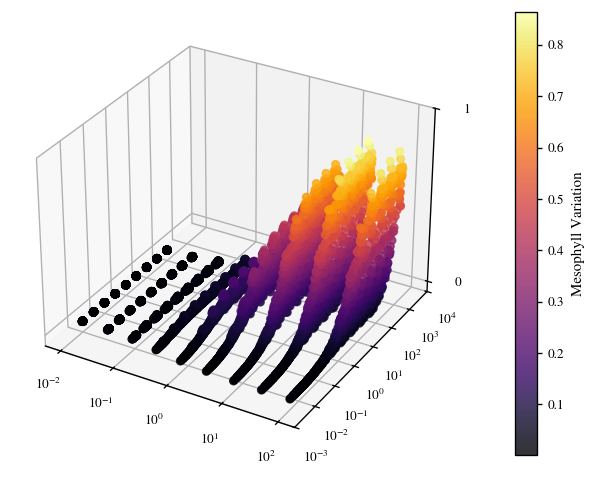

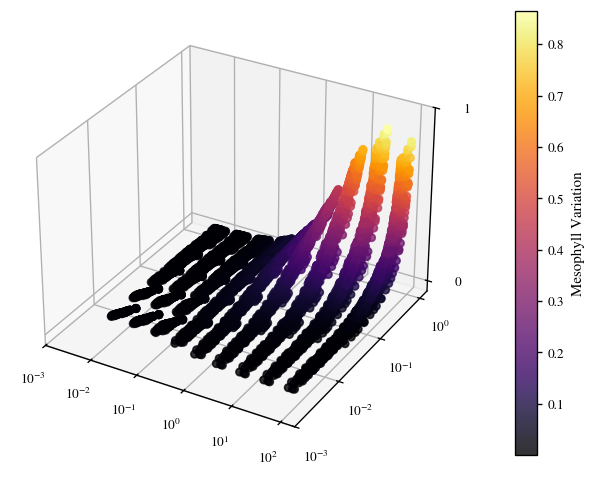

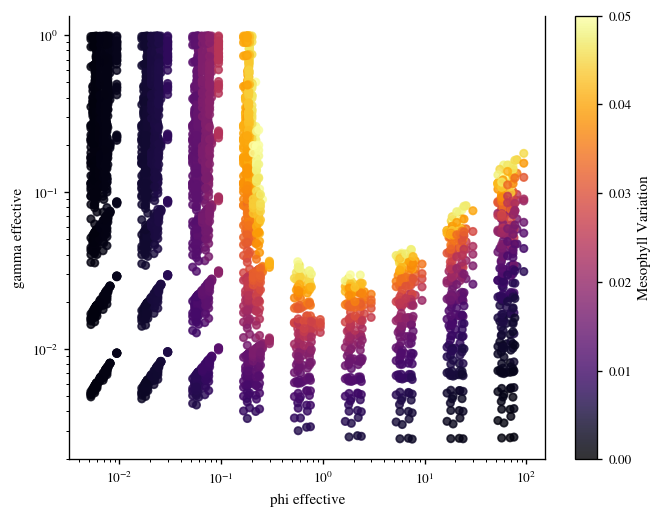

In [116]:
# Plot coefficient of variation over cell surfaces first in (phi, gamma), then in (phi', gamma')

phi_eff = df["diffusive_pipe_resistance_m"] * df["absorption"] # how does cell-domain diffusion compare to absorption?
gamma_eff = df["diffusive_pipe_resistance_m"] / (df["diffusive_resistance_m"] + 1/df["transport"]) # what fraction of the total resistance is due to the cell domain?

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    df["mesophyll_variation"],
    c=df["mesophyll_variation"],
    logz=False,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Mesophyll Variation")
plt.show()


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    phi_eff,
    gamma_eff,
    df["mesophyll_variation"],
    c=df["mesophyll_variation"],
    logz=False,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Mesophyll Variation")
plt.show()


# filter for points with variation less than threshold
threshold = 0.05
mask = df["mesophyll_variation"] < threshold
# plot 2D projection of these points in (phi, gamma) space
fig = plt.figure()
ax = fig.add_subplot(111)
sc = ax.scatter(
    phi_eff[mask],
    gamma_eff[mask],
    c=df[mask]["mesophyll_variation"],
    cmap="inferno",
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=threshold,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mesophyll Variation")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("phi effective")
ax.set_ylabel("gamma effective")
plt.show()


### Does Photoactivity affect only pipe contribution? And does total resistance approach diffusive estimate for $\phi \rightarrow 0$?

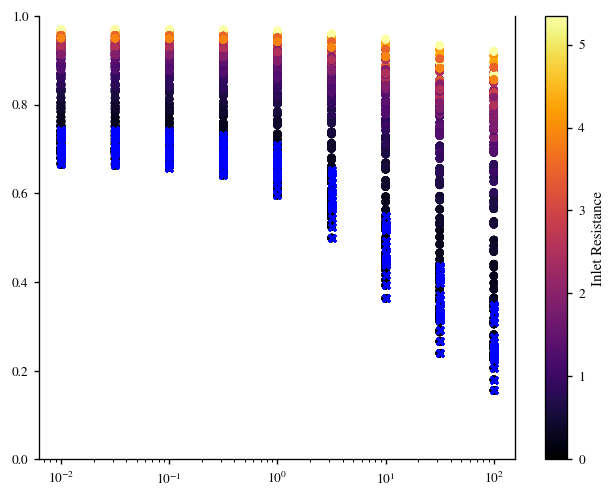

In [117]:

sc  = plt.scatter(df["absorption"], df["resistance_m"]/df["diffusive_resistance_m"], c=df["diffusive_inlet_resistance"], cmap="inferno")


mask = df["specifier"] == 0
photo_pipe_resistance = df[mask]["resistance_m"]
diff_pipe_estimate = df[mask]["diffusive_resistance_m"]
sc_ = plt.scatter(df[mask]["absorption"], (photo_pipe_resistance)/diff_pipe_estimate, color="blue", marker="x", zorder=3)


cbar = plt.colorbar(sc)
cbar.set_label("Inlet Resistance")
plt.xscale("log")
plt.ylim(0, 1)
plt.show()

We see that the diffusive and photoactive definition only agree for low $\phi$ and when $r_{inlet}$ dominates the drawdown. When there is no resistance from inlet dissipation (blue) we actually see the photoactive resistance converge at a roughly 70% smaller number than diffusion predicts

### Using diffusive estimates, what are the associated errors in mean conc. and assimilaton rate? ($\delta U = 0$ case)

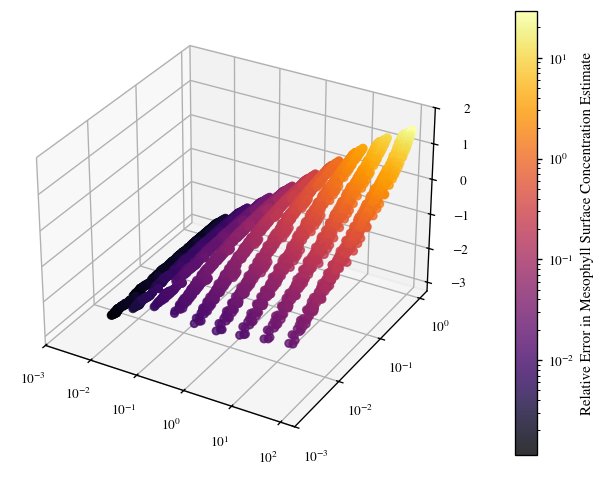

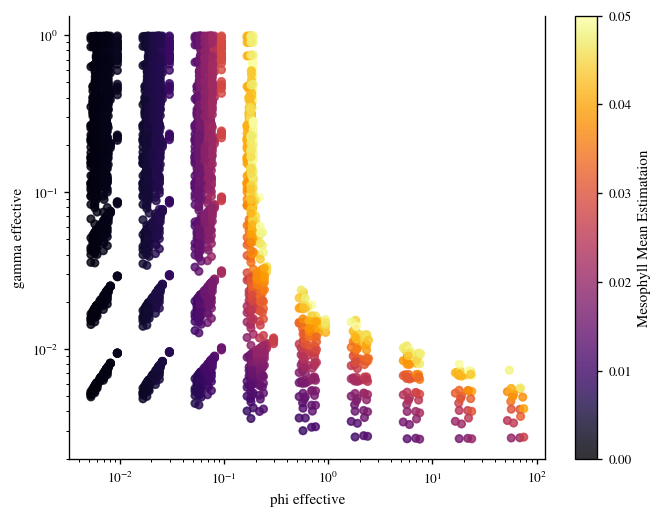

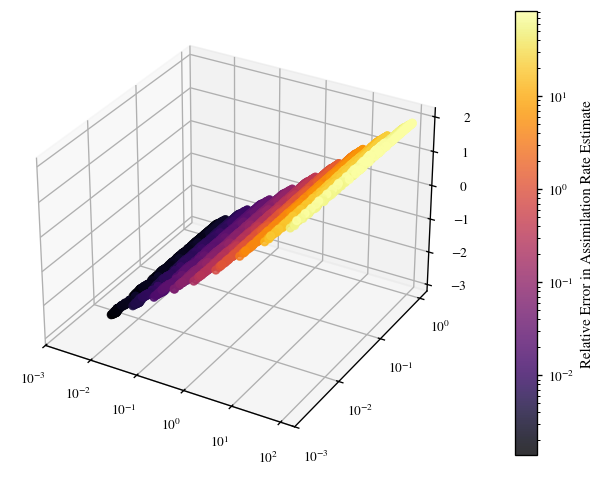

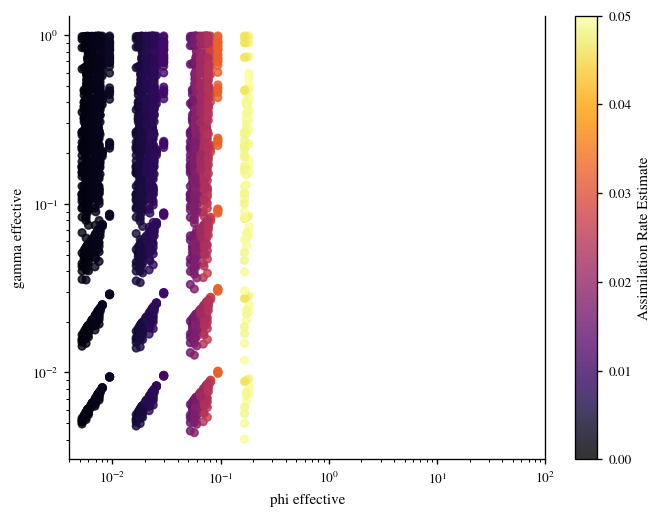

In [124]:
chim = df["mesophyll_mean"]
chim_diffusion = df["substomatal_mean"] - df["diffusive_resistance_m"] * df["assimilation_rate"] 

rel_err = (chim - chim_diffusion) / chim

# make a log distributed colormap 
from matplotlib.colors import LogNorm
cmap = plt.get_cmap("inferno")
norm = LogNorm(vmin=rel_err.min(), vmax=rel_err.max())

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    phi_eff,
    gamma_eff,
    rel_err,
    c=rel_err,
    logz=True,
    cmap="inferno",
    norm=norm,
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Relative Error in Mesophyll Surface Concentration Estimate")
plt.show()


threshold = 0.05
mask = rel_err < threshold
# plot 2D projection of these points in (phi, gamma) space
fig = plt.figure()
ax = fig.add_subplot(111)
sc = ax.scatter(
    phi_eff[mask],
    gamma_eff[mask],
    c=rel_err[mask],
    cmap="inferno",
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=threshold,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mesophyll Mean Estimataion")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("phi effective")
ax.set_ylabel("gamma effective")
plt.show()




# ============================================


assim_diffusion = df["absorption"] * (chim_diffusion - df["compensation"])
rel_err= np.abs(df["assimilation_rate"] - assim_diffusion) / df["assimilation_rate"]


norm = LogNorm(vmin=rel_err.min(), vmax=rel_err.max())

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    phi_eff,
    gamma_eff,
    rel_err,
    c=rel_err,
    logz=True,
    cmap="inferno",
    norm=norm,
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Relative Error in Assimilation Rate Estimate")
plt.show()

threshold = 0.05
mask = rel_err < threshold
# plot 2D projection of these points in (phi, gamma) space
fig = plt.figure()
ax = fig.add_subplot(111)
sc = ax.scatter(
    phi_eff[mask],
    gamma_eff[mask],
    c=rel_err[mask],
    cmap="inferno",
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=threshold,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Assimilation Rate Estimate")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("phi effective")
ax.set_ylabel("gamma effective")
ax.set_xlim(4e-3, 1e2)
plt.show()


### Phase plots of usual quantities

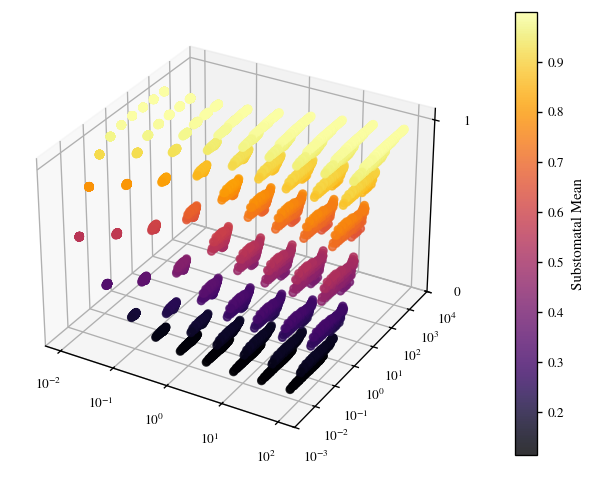

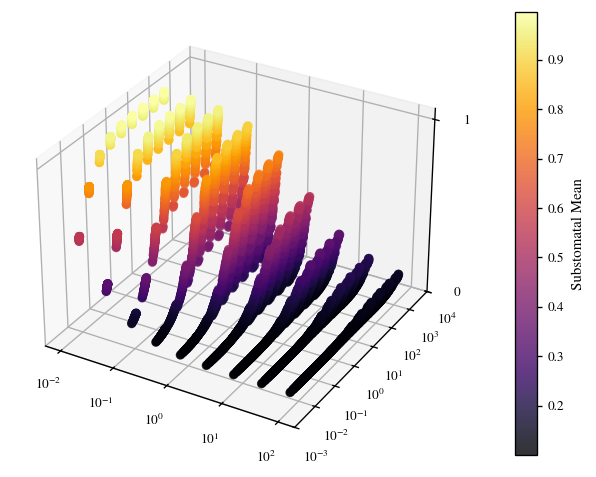

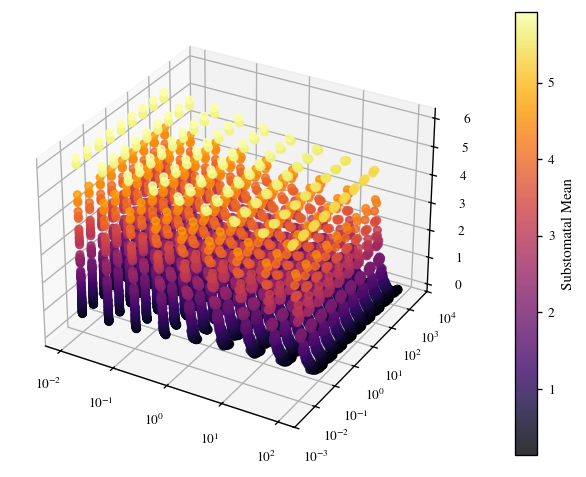

In [135]:
values = df["substomatal_mean"]


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    values,
    c=values,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Substomatal Mean")
plt.show()

values = df["mesophyll_mean"]


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    values,
    c=values,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Substomatal Mean")
plt.show()

values = df["resistance_m"]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    values,
    c=values,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Substomatal Mean")
plt.show()